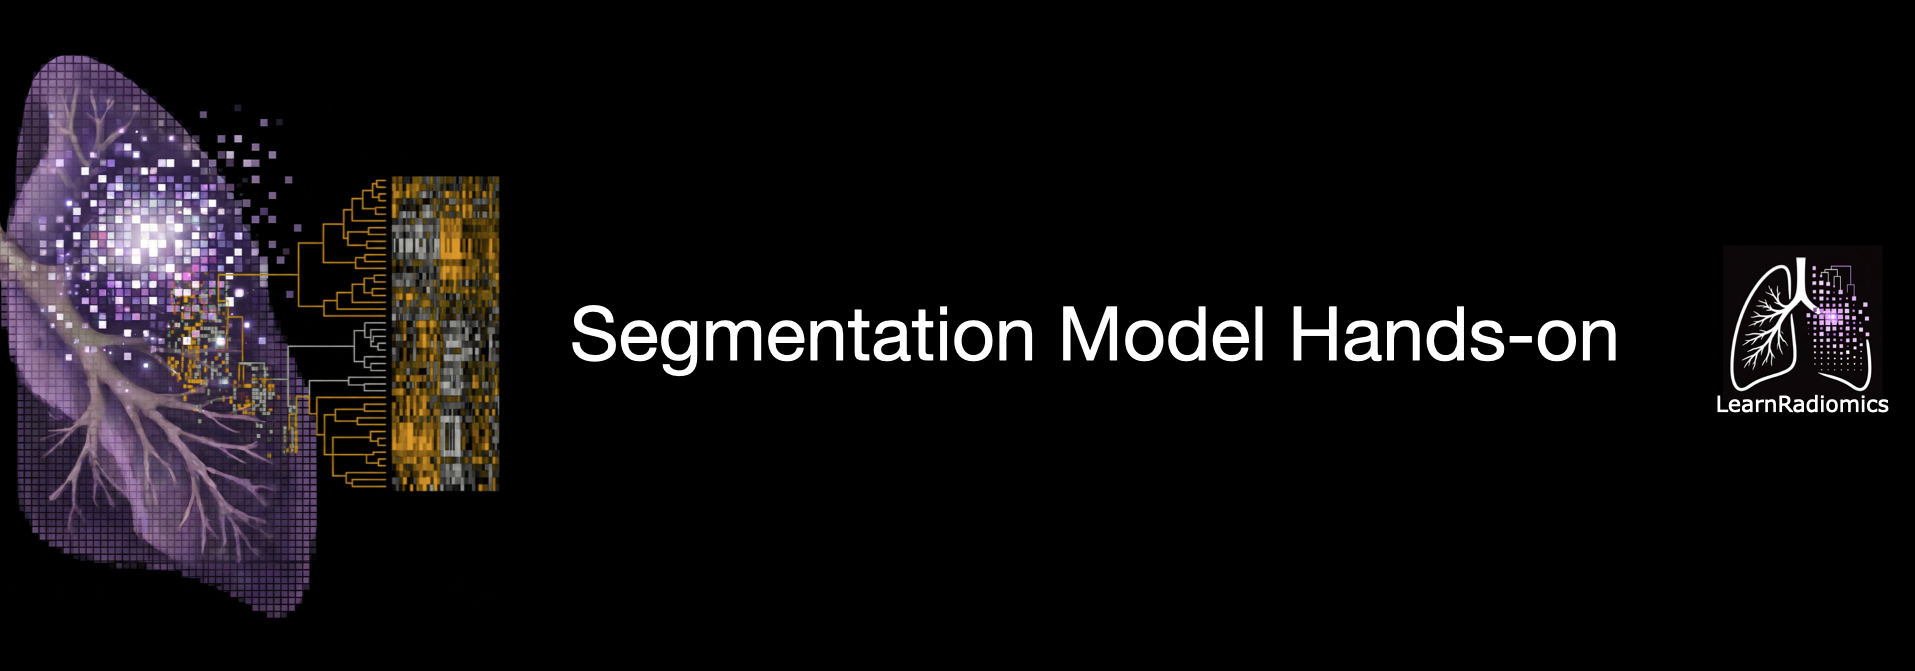

In [ ]:
!pip install -q seg-metrics visualkeras

In [ ]:
## General Libraries

import numpy as np
import matplotlib.pyplot as plt
import os
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from tqdm import trange
import requests
import json
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import seg_metrics.seg_metrics as sg
from scipy.ndimage import median_filter
from scipy.ndimage import binary_erosion
from skimage.measure import label, regionprops
#import nibabel as nib
#from nibabel.processing import resample_to_output
import SimpleITK as sitk


import tensorflow as tf
import tensorflow.keras.layers as L
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPool2D, UpSampling2D, Concatenate
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import SGD, RMSprop, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras  import losses
from tensorflow.keras.utils import Sequence

## Warnings
import warnings
warnings.filterwarnings('ignore')

## Downloading Tokens for data access
json_response= requests.get("https://raw.github.com/HectorHenriquez/Airway_segmentation/main/kaggle.json")
token = json.loads(json_response.text)
with open("kaggle.json", "w") as outfile:
    json.dump(token, outfile)

## Load Kaggle Data
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

## Dataset
! kaggle datasets download hshenriquez/airway-segmentation-hands-on
! unzip -q /content/airway-segmentation-hands-on.zip

In [ ]:
## Histogram Adjustment

def show_slice_window(slice, level, window):
    """
    input: imagen array 2D,
    permite ajustar ventana y nivel para mejorar contraste de la imagen.
    output: imagen array 2D ventaneada.
   """
    max = level + window/2
    min = level - window/2
    slice = slice.clip(min,max)
    return(slice)


# Data Agumentation Functions
def augment(image, mask):
  image = tf.cast(image, tf.float32)
  mask = tf.cast(mask, tf.float32)
  # Horizontal Flip
  if tf.random.uniform(()) > 0.5:
    image = tf.image.flip_left_right(image)
    mask = tf.image.flip_left_right(mask)
    # Vertical Flip
  if tf.random.uniform(()) > 0.5:
    image = tf.image.flip_up_down(image)
    mask = tf.image.flip_up_down(mask)
    # Brightness
  if tf.random.uniform(()) > 0.5:
    image = tf.image.random_brightness(image, max_delta=0.1)
    # Contrast
  if tf.random.uniform(()) > 0.5:
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    # 90 degree rotation
  if tf.random.uniform(()) > 0.5:
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)
    # Binary mask
  mask = tf.round(mask)

  return (image, mask)

### Segmentation Metrics and Loss Function
def dice_coeff(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    return (score)

def dice_loss(y_true, y_pred):
    loss = 1 - dice_coeff(y_true, y_pred)
    return (loss)

def bce_dice_loss(y_true, y_pred):
    loss = losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)
    return (loss)

### Prediction postprocessing
def remove_small_connected_components(volume, min_size=50):
    """
    Removes small connected components from a 3D image volume.
    param volume: np.array, binary segmentation volume (0s and 1s)
    param min_size: int, minimum size of connected components to retain
    return: np.array, volume with the removed small components
    """

    labeled_volume, num_features = label(volume, return_num=True)

    cleaned_volume = np.zeros_like(volume)

    for region in regionprops(labeled_volume):

        if region.area >= min_size:
            cleaned_volume[labeled_volume == region.label] = 1

    return (cleaned_volume)

## Visualization and Volume Calculation
def visualize_3d_mask_labels_sampled(mask, sample_frac=0.1, alpha=0.5, colormap='dodgerblue', title=""):
    zs, ys, xs = np.where(mask > 0)
    vals = mask[zs, ys, xs]
   # Sampling
    n = len(zs)
    idx = np.random.choice(n, size=int(n*sample_frac), replace=False)
    zs, ys, xs, vals = zs[idx], ys[idx], xs[idx], vals[idx]

    fig = go.Figure()
    for lbl in np.unique(vals):
        sel = vals == lbl
        fig.add_trace(go.Scatter3d(
            x=xs[sel], y=ys[sel], z=zs[sel],
            mode='markers',
            name=f"Label {lbl}",
            marker=dict(size=2, color = colormap ,opacity=alpha)
        ))
    fig.update_layout(title=title,
                      scene=dict(xaxis_title='X', yaxis_title='Y', zaxis_title='Z'))
    fig.show()


In [ ]:
def normalize_ct_to_minus_one_one(
    image_array,
    hu_min=-1024,
    hu_max=2048,
    extreme_low_threshold=-2000
):
    """
    Normalize a CT image to the range [-1, 1].
    1. Replace extremely low values, such as padding -3024.
    2. Apply HU clipping.
    3. Scale to [-1, 1].

    """

    image_array = image_array.astype(np.float32)

    image_array[~np.isfinite(image_array)] = hu_min

    # Valores muy bajos suelen corresponder a padding/background
    image_array[image_array < extreme_low_threshold] = hu_min

    # Clipping HU
    image_array = np.clip(image_array, hu_min, hu_max)

    # Escalar a [0, 1]
    image_array = (image_array - hu_min) / (hu_max - hu_min)

    # Escalar a [-1, 1]
    image_array = 2.0 * image_array - 1.0

    return image_array.astype(np.float32)


def resize_sitk_image(
    image,
    target_size_zyx,
    is_mask=False
):
    """
   Resizes a SimpleITK 3D image to a fixed size.

    Parameters
    ----------
    image : sitk.Image
    3D image or mask.
    target_size_zyx : tuple
    Final size in (Z, Y, X) format, for example (128, 128, 128).
    is_mask : bool
    If True, uses nearest neighbor interpolation.

    Returns
    -------
    resized : sitk.Image
    Resized image.
    """

    original_size_xyz = np.array(image.GetSize(), dtype=np.int32)       # (X, Y, Z)
    original_spacing_xyz = np.array(image.GetSpacing(), dtype=np.float32)

    target_size_xyz = np.array(
        [target_size_zyx[2], target_size_zyx[1], target_size_zyx[0]],
        dtype=np.int32
    )

    new_spacing_xyz = original_spacing_xyz * (original_size_xyz / target_size_xyz)

    resampler = sitk.ResampleImageFilter()
    resampler.SetSize([int(s) for s in target_size_xyz])
    resampler.SetOutputSpacing([float(s) for s in new_spacing_xyz])
    resampler.SetOutputOrigin(image.GetOrigin())
    resampler.SetOutputDirection(image.GetDirection())

    if is_mask:
        resampler.SetInterpolator(sitk.sitkNearestNeighbor)
        resampler.SetDefaultPixelValue(0)
    else:
        resampler.SetInterpolator(sitk.sitkLinear)
        resampler.SetDefaultPixelValue(-1024)

    resized = resampler.Execute(image)

    return resized

In [ ]:
## Images and Masks Paths
PATH_IMG = '/content/data_cropped/images'
PATH_MASK = '/content/data_cropped/masks'

In [ ]:
## Patients list

patients = [patient[0:9] for patient in os.listdir(PATH_IMG)]

train_patients, test_patients, _ , _ = train_test_split(
    patients, patients, test_size=0.15, random_state=42)

print(len(train_patients))
print(len(test_patients))


In [ ]:
## Dataset Building: train
X_train = []
y_train = []

for patient in train_patients:
  path_img = os.path.join(PATH_IMG, f'{patient}_img_cropped.nii')
  path_mask = os.path.join(PATH_MASK, f'{patient}_mask_cropped.nii')

  img_itk = sitk.ReadImage(path_img)
  mask_itk = sitk.ReadImage(path_mask)

  img_res = resize_sitk_image(img_itk,target_size_zyx=(180,128,128), is_mask=False)
  mask_res = resize_sitk_image(mask_itk,target_size_zyx=(180,128,128), is_mask=True)

  img_array = sitk.GetArrayFromImage(img_res)
  img_array = normalize_ct_to_minus_one_one(img_array)
  mask_array = sitk.GetArrayFromImage(mask_res)

  X_train.extend(img_array.reshape(180,128,128,1))
  y_train.extend(mask_array.reshape(180,128,128,1))

In [ ]:
## Dataset Building: test (internal validation)
X_test = []
y_test = []

for patient in test_patients:
  path_img = os.path.join(PATH_IMG, f'{patient}_img_cropped.nii')
  path_mask = os.path.join(PATH_MASK, f'{patient}_mask_cropped.nii')

  img_itk = sitk.ReadImage(path_img)
  mask_itk = sitk.ReadImage(path_mask)

  img_res = resize_sitk_image(img_itk,target_size_zyx=(180,128,128), is_mask=False)
  mask_res = resize_sitk_image(mask_itk,target_size_zyx=(180,128,128), is_mask=True)

  img_array = sitk.GetArrayFromImage(img_res)
  img_array = normalize_ct_to_minus_one_one(img_array)
  mask_array = sitk.GetArrayFromImage(mask_res)

  X_test.extend(img_array.reshape(180,128,128,1))
  y_test.extend(mask_array.reshape(180,128,128,1))

In [ ]:
## Transform lists to numpy arrays.
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


In [ ]:
level = -400
window_width = 1200

index = np.random.randint(0, X_train.shape[0])
img = X_train[index]
mask = y_train[index]


f = plt.figure(figsize=(10,10), frameon=True)

f.add_subplot(1, 3, 1)
plt.title("CT")
plt.imshow(show_slice_window(img,level,window_width), cmap='gray')

f.add_subplot(1, 3, 2)
plt.title("Mask")
plt.imshow(mask, cmap='Blues')

f.add_subplot(1, 3, 3)
plt.title("Fusión")
plt.imshow(show_slice_window(img,level,window_width), cmap='gray')
plt.imshow(mask, cmap='gnuplot', alpha= 0.6)

plt.show()

In [ ]:

### Each patient has 180 images; you can select indices in ranges of 180,
### or test random patients.

random_index = np.random.randint(0,22)
index_start = random_index*180
index_end = random_index*180+180
print("rango paciente:", index_start, index_end)

mask = y_train[index_start:index_end]

visualize_3d_mask_labels_sampled(mask[..., 0], sample_frac=0.6, alpha=0.9, title="3D segmentation")

### Data augmentation

In [ ]:
## Define the dataset on which data augmentation is performed
## Only training data is considered:
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

## The data augmentation function is applied to the dataset
augmented_dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

## Prepare the dataset for training
## Number of images generated

batch_size = 16
augmented_dataset = augmented_dataset.shuffle(buffer_size=1000)
augmented_dataset = augmented_dataset.batch(batch_size)
augmented_dataset = augmented_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:

## Visualizing Random Image Transformations
## Random Cases

index = np.random.randint(0, X_train.shape[0])
original_image = X_train[index]
original_mask = y_train[index]

# Conversion to image tensors and mask
original_image_tensor = tf.convert_to_tensor(original_image)
original_mask_tensor = tf.convert_to_tensor(original_mask)

# Expand dimensions if necessary
original_image_tensor = tf.expand_dims(original_image_tensor, 0)
original_mask_tensor = tf.expand_dims(original_mask_tensor, 0)

# Apply the zoom function
augmented_image, augmented_mask = augment(original_image_tensor, original_mask_tensor)

# Convert tensors to numpy arrays
original_image = original_image_tensor.numpy().squeeze()
original_mask = original_mask_tensor.numpy().squeeze()
augmented_image = augmented_image.numpy().squeeze()
augmented_mask = augmented_mask.numpy().squeeze()

# View the images and masks
f = plt.figure(figsize=(10,15))
f.add_subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_image.astype('float32'), cmap = 'gray')
plt.imshow(original_mask, cmap='inferno', alpha = 0.5)

f.add_subplot(1, 2, 2)
plt.title("Augmented Image")
plt.imshow(augmented_image.astype('float32'), cmap='gray')
plt.imshow(augmented_mask, cmap='rainbow', alpha = 0.4)

plt.tight_layout()
plt.show()

# Segmentation Model Construction


In [ ]:
## Bloque Convolucional Estándar
def conv_block(x, num_filters):
    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)
    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("relu")(x)
    return (x)

## Vía Encoder
def encoder_block(x, num_filters):
    x = conv_block(x, num_filters)
    p = L.MaxPool2D((2, 2))(x)
    return (x, p)

## Mecanismo de atención
def attention_gate(g, s, num_filters):
    Wg = L.Conv2D(num_filters, 1, padding="same")(g)
    Wg = L.BatchNormalization()(Wg)

    Ws = L.Conv2D(num_filters, 1, padding="same")(s)
    Ws = L.BatchNormalization()(Ws)

    out = L.Activation("relu")(Wg + Ws)
    out = L.Conv2D(num_filters, 1, padding="same")(out)
    out = L.Activation("sigmoid")(out)
    return (out * s)

## Vía Decoder
def decoder_block(x, s, num_filters):
    x = L.UpSampling2D(interpolation="bilinear")(x)
    s = attention_gate(x, s, num_filters)
    x = L.Concatenate()([x, s])
    x = conv_block(x, num_filters)
    return (x)

### Arquitectura general del Modelo
def attention_unet(input_shape):
    """ Inputs """
    inputs = L.Input(input_shape)

    """ Encoder """
    s1, p1 = encoder_block(inputs, 32)
    s2, p2 = encoder_block(p1, 64)
    s3, p3 = encoder_block(p2, 128)

  ## Bottle Neck
    b1 = conv_block(p3, 256)

    """ Decoder """
    d1 = decoder_block(b1, s3, 128)
    d2 = decoder_block(d1, s2, 64)
    d3 = decoder_block(d2, s1, 32)

    """ Outputs """
    outputs = L.Conv2D(1, 1, padding="same", activation="sigmoid")(d3)

    """ Model """
    model = Model(inputs, outputs, name="Attention-UNET")
    return(model)

In [ ]:
## Model Creation
## Image size: 128 x 128, with 1 color channel (black and white)

if __name__ == "__main__":
    input_shape = (128, 128, 1)
    model = attention_unet(input_shape)
    model.summary()


### Training the model

In [ ]:
epochs = 30
LR = 0.005

###  Callbacks:
def scheduler(epoch, learning_rate):
    if epoch < 20:
        return learning_rate
    else:
        return learning_rate * np.exp(-0.05)

lr_scheduler = LearningRateScheduler(scheduler)

checkpoint_filepath = './checkpoint.weights.h5'

model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='min',
    save_best_only=True)

model.compile(optimizer=Adam(learning_rate=LR), loss = bce_dice_loss)

history = model.fit(augmented_dataset,
                    epochs=epochs, verbose=1, shuffle= False,
                    callbacks=[lr_scheduler, model_checkpoint_callback],
                    validation_data=(X_test, y_test))

model.load_weights(checkpoint_filepath)

In [ ]:
## Save the model
#model.save('/content/modelo_segmentacion_via_aerea_128x128.keras')


## Loss Function graph

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))

plt.plot(epochs, loss, 'b', label='Training loss', color='salmon')
plt.plot(epochs, val_loss, 'b', label='Validation loss', color='dodgerblue')
plt.title('Training and validation loss')
plt.legend()
plt.show()


### Model Evaluation

In [ ]:
## Test group loss function
model.evaluate(X_test, y_test)

In [ ]:
## Predictions
predicciones = model.predict(X_test)

### Postprocessing of prediction masks

* You can explore some general post-processing techniques.

In [ ]:
## Thresholding
predicciones_bin = np.where(predicciones>0.5,1,0)

## Removal of small, unconnected convex elements
## A minimum size is defined for elements that will be removed if they are not connected
predicciones_bin = remove_small_connected_components(predicciones_bin.reshape(predicciones_bin.shape[0],128,128), min_size=10)



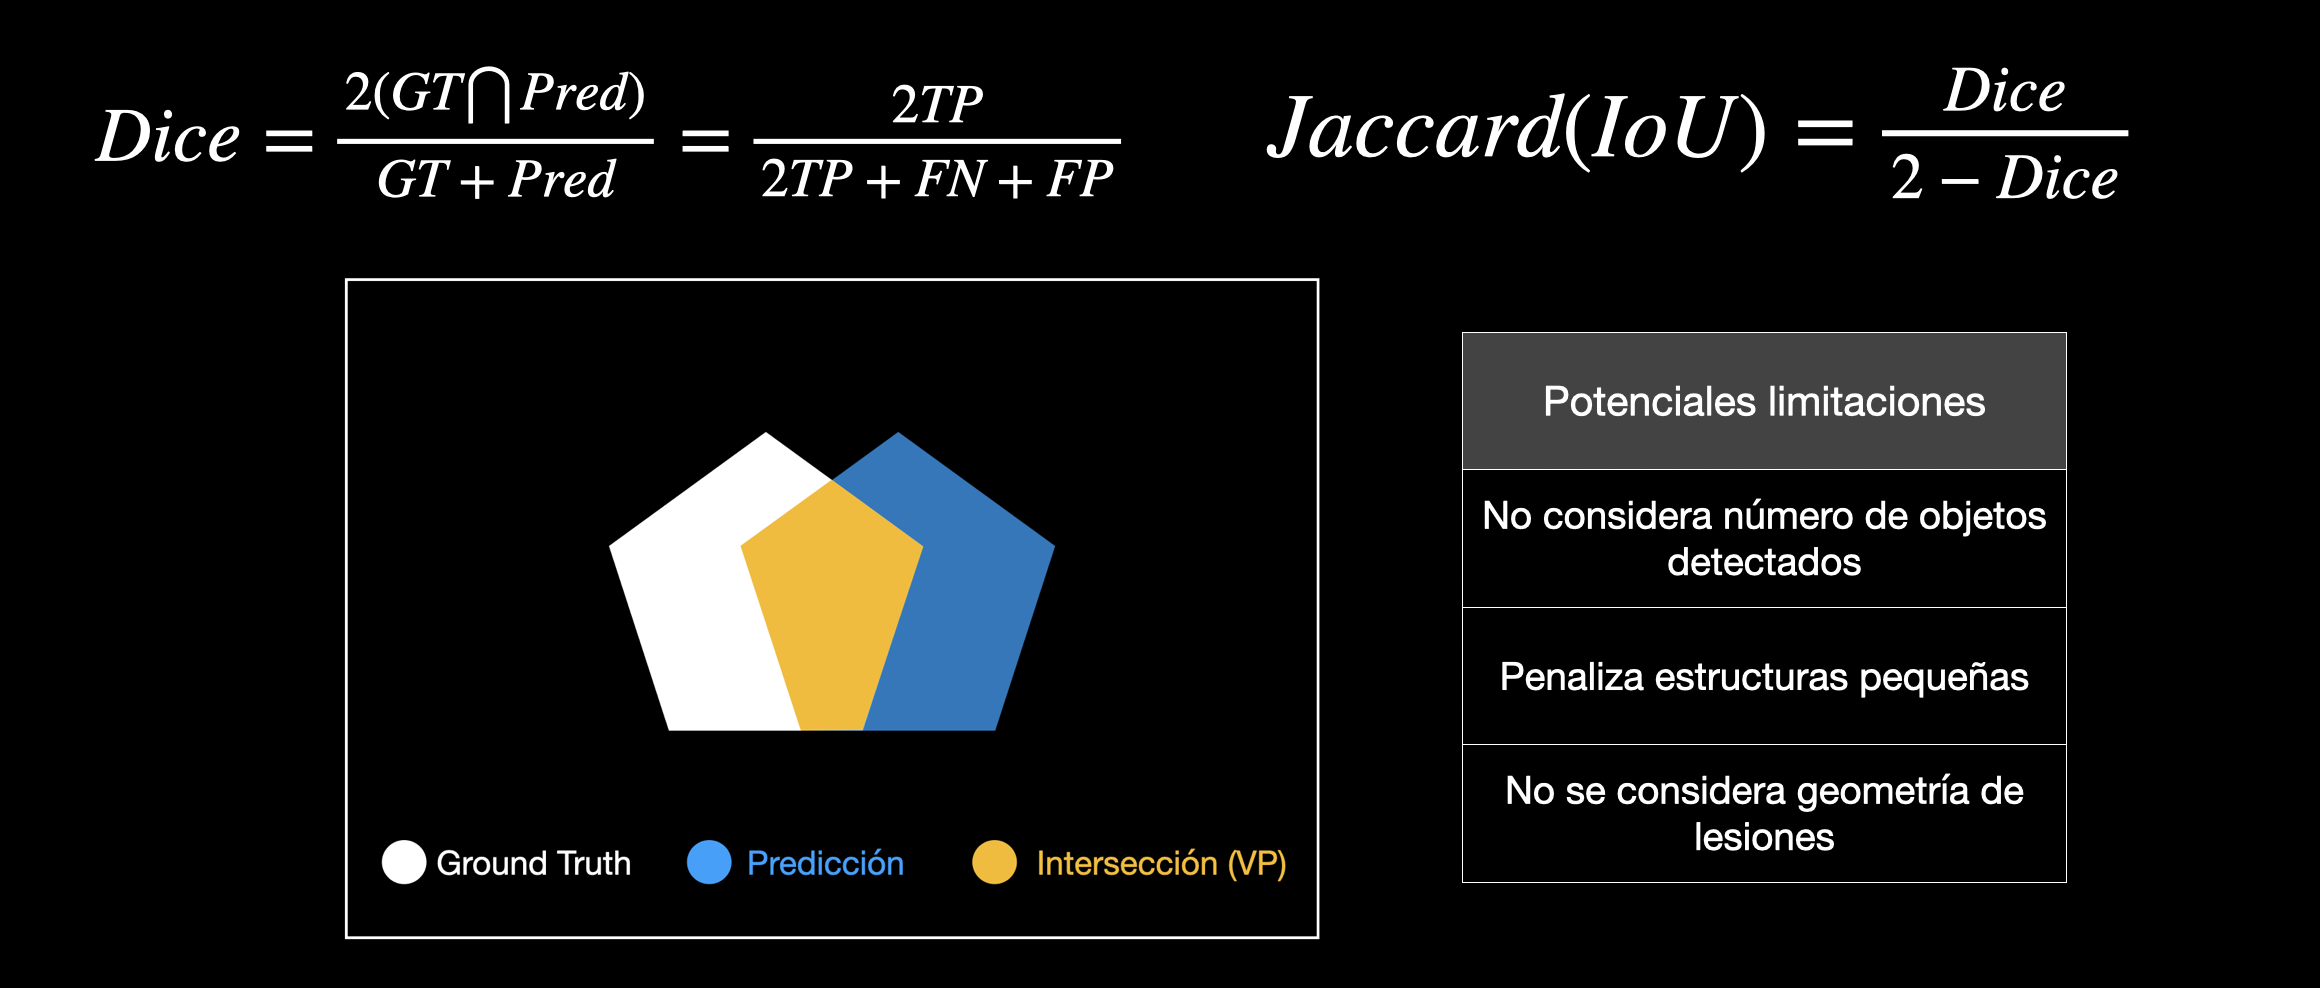

In [ ]:
score_dice = dice_coeff(y_test.astype('float32'), predicciones_bin.astype('float32')).numpy()
print("DICE score in Test group:", round(score_dice,3))

In [ ]:
random_index = np.random.randint(0,5)
index_start = random_index*180
index_end = random_index*180+180
print("rango paciente:", index_start, index_end)
#index_start = 180
#index_end = 360

test_mask = predicciones_bin[index_start:index_end]

print(test_mask.shape)
visualize_3d_mask_labels_sampled(test_mask, sample_frac=0.8, alpha=0.8, colormap='mediumorchid', title="3D segmentation - prediction")


In [ ]:
### Evaluation

index = np.random.randint(0, X_test.shape[0])

img = X_test[index]
mask = y_test[index]

metrics = sg.write_metrics(labels=[0,1],
                  gdth_img=mask,
                  pred_img=predicciones_bin.reshape(900,128,128,1)[index],
                  csv_file=None,
                  spacing=None,
                  metrics=['dice', 'jaccard'])

f = plt.figure(figsize=(15,15), frameon=False)
f.add_subplot(1, 3, 1)
plt.title("CT + GoundTruth")
plt.imshow(img, cmap='gray')
plt.imshow(mask, cmap='copper', alpha= 0.4)

f.add_subplot(1, 3, 2)
plt.title("Predicción")
plt.imshow(img, cmap='gray')
plt.imshow(predicciones_bin[index], cmap='gnuplot', alpha=0.4)
plt.contour(predicciones_bin[index], levels=[0.5], linewidths=2)


f.add_subplot(1, 3, 3)
plt.title("Evaluación Modelo: GT vs Predicción")
plt.imshow(mask, cmap='Blues')
plt.imshow(predicciones_bin[index], cmap='Blues_r', alpha= 0.7)
plt.text(83, 10, "Dice Score: {}".format(round(metrics[0]['dice'][1],2)), size=12, va="center", ha="center", rotation=0)
plt.text(85, 25, "Jaccard Score: {}".format(round(metrics[0]['jaccard'][1],3)), size=12, va="center", ha="center", rotation=0)
plt.show()